# CICLe on SST-5

Model: **Llama 3.1-8B** | Embedding: **contriever** | Base classifier: **logistic regression** | shots: **2** | variant: **pc** | alpha: **0.05**

CICLe combines a conformal base classifier with in-context learning: the base classifier proposes a (small) set of candidate classes that is guaranteed to contain the true class with probability 0.95, and an LLM is then prompted with a few examples to pick the final label from that set.

### Prerequisites:

Before we dive into the implementation, we have to install some prerequisites:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Llama 3.1-8B for prompting

Furthermore, we will perform our experiments on the [SST-5 dataset](https://huggingface.co/datasets/SetFit/sst5).

In [1]:
%%capture
# install dependencies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers sentence-transformers accelerate tqdm datasets

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("SetFit/sst5", split="train")
test_data = load_dataset("SetFit/sst5", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Repo card metadata block was not found. Setting CardData to empty.


Repo card metadata block was not found. Setting CardData to empty.


Train set size: 8544 examples
Test set size: 2210 examples


In [3]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter out empty texts:
train_df = train_df[train_df['text'].str.strip().astype(bool)]
test_df = test_df[test_df['text'].str.strip().astype(bool)]

train_df.sample()

,text,label,label_text
7991,an effortlessly accomplished and richly resona...,4,very positive


In [4]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

# create the development set:
train_df, dev_df = train_test_split(
    train_df, stratify=train_df["label"], test_size=0.2, shuffle=True, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Dev subset size: {len(dev_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 1600 examples
Dev subset size: 400 examples
Test subset size: 1000 examples


We use the sentiment category (`label_text`) associated with each review `text` as the target category to predict:

In [5]:
# use the sentiment name as the target label:
train_df['label_name'] = train_df['label_text']
dev_df['label_name'] = dev_df['label_text']
test_df['label_name'] = test_df['label_text']

In [6]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label_name'].to_numpy()

X_dev = dev_df['text'].to_numpy()
y_dev = dev_df['label_name'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label_name'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  5


### Train base classifier

We import the Contriever model from `transformers` and use it to create dense vector embeddings for our texts. We define a utility function (`phi`) that encodes a list of texts into embeddings using the model, applying mean pooling over token embeddings.

In [7]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# load Contriever model
tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
model = AutoModel.from_pretrained("facebook/contriever")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# mean pooling function
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1)

# define embedding function (batched to avoid OOM):
def phi(texts, batch_size=32):
    if hasattr(texts, "tolist"):
        texts = texts.tolist()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=512
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

# test embedding shape
phi(X_train[:2].tolist()).shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 768)

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration.

In [8]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l: i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'negative': 0,
 'neutral': 1,
 'positive': 2,
 'very negative': 3,
 'very positive': 4}

Now let's train our conformal base classifier! We use the `WrapClassifier` class from `crepes` wrapping logistic regression. We train it on `phi(X_train)` and calibrate it on `phi(X_dev)` using class-conditional calibration (`class_cond=True`).

In [9]:
from crepes import WrapClassifier
from sklearn.linear_model import LogisticRegression

# create a conformal base classifier based on Logistic Regression:
base_classifier = WrapClassifier(LogisticRegression(max_iter=1000))

# train the base classifier:
X_train_emb = phi(X_train)
base_classifier.fit(
    X_train_emb,
    [label2id[y] for y in y_train]
)

# calibrate the base classifier:
base_classifier.calibrate(
    phi(X_dev),
    [label2id[y] for y in y_dev],
    class_cond=True
)

WrapClassifier(learner=LogisticRegression(max_iter=1000), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [10]:
# pre-compute test embeddings before loading LLM:
print("Pre-computing test embeddings...")
X_test_emb = phi(X_test)
print(f"X_train_emb: {X_train_emb.shape}, X_test_emb: {X_test_emb.shape}")

import gc

# free embedding model from GPU to make room for LLM:
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Contriever freed from GPU memory.")

Pre-computing test embeddings...


X_train_emb: (1600, 768), X_test_emb: (1000, 768)


Contriever freed from GPU memory.


### Instantiate Llama 3.1-8B

In order to be able to use huggingface's Llama 3.1-8B model, we first need to log in to huggingface (you may need to request access depending on the model).

In [11]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for Llama 3.1-8B.

In [12]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="meta-llama/Meta-Llama-3.1-8B-Instruct",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto"
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.convert_tokens_to_ids('<|begin_of_text|>')
eos_token_id = llm.tokenizer.convert_tokens_to_ids('<|eot_id|>')
pad_token_id = llm.tokenizer.convert_tokens_to_ids('<|eot_id|>')

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

### Results Handling Helper

In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json
import numpy as np

def save_results(y_true, y_pred, classes, filename="results.json", set_sizes=None):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.
    set_sizes, if given, is the per-test-example conformal prediction set size
    (len(ps)), used to analyse the effect of the conformal filter on CICLe.
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes
    }

    if set_sizes is not None:
        set_sizes = [int(s) for s in set_sizes]
        results["conformal_set_sizes"] = {
            "values": set_sizes,
            "n_empty": sum(1 for s in set_sizes if s == 0),
            "n_singleton": sum(1 for s in set_sizes if s == 1),
            "n_llm": sum(1 for s in set_sizes if s > 1),
            "mean": float(np.mean(set_sizes)),
        }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [14]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file,
    including summary statistics.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### CICLe

`get_few_shot_examples` returns, for each class in the conformal prediction set, the `examples_per_class` most similar training examples (by cosine similarity over the precomputed embeddings), sorted globally by similarity.

In [15]:
from sklearn.metrics import pairwise_distances

def get_few_shot_examples(test_idx, prediction_set, examples_per_class=2):
    examples = []
    test_emb = X_test_emb[test_idx:test_idx+1]

    for y in prediction_set:
        # get texts and pre-computed embeddings for current class:
        mask = y_train == y
        texts = X_train[mask]
        train_embs = X_train_emb[mask]

        # calculate cosine similarity using pre-computed embeddings:
        all_embs = np.vstack([test_emb, train_embs])
        similarity = (1. - pairwise_distances(all_embs, metric='cosine'))[1:, 0]

        # get closest sample of training data based on embeddings:
        for j in np.argsort(similarity)[::-1][:examples_per_class]:
            examples.append((texts[j], y, similarity[j]))

    # sort samples based on similarity:
    examples.sort(key=lambda e: e[2], reverse=True)

    return examples

In [16]:
# print sample output:
samples = get_few_shot_examples(
    0,
    id2label[base_classifier.predict_set(X_test_emb[:1], confidence=0.95).astype(bool)[0]],
    examples_per_class=2
)
samples

[("the story of trouble every day ... is so sketchy it amounts to little more than preliminary notes for a science-fiction horror film , and the movie 's fragmentary narrative style makes piecing the story together frustrating difficult .",
  'very negative',
  np.float32(0.496265)),
 ('the dramatic scenes are frequently unintentionally funny , and the action sequences -- clearly the main event -- are surprisingly uninvolving .',
  'negative',
  np.float32(0.48801625)),
 ('... grows decidedly flimsier with its many out-sized , out of character and logically porous action set pieces .',
  'very negative',
  np.float32(0.48680556)),
 ("the most repugnant adaptation of a classic text since roland joffé and demi moore 's the scarlet letter .",
  'negative',
  np.float32(0.4805959)),
 ("the gentle comic treatment of adolescent sturm und drang should please fans of chris fuhrman 's posthumously published cult novel .",
  'positive',
  np.float32(0.47083008)),
 ("although olivier assayas ' el

In [17]:
def create_prompt(text, examples):
    # helper function replacing quotation marks in the text:
    replace_qm = lambda s: s.replace('"', "'")

    # create context:
    context = f'We classify movie review snippets into sentiment categories based on their text. Here are some labelled examples sorted from most probable to least probable:\n'

    for x, y, _ in examples:
        context += f'\n"{replace_qm(x)}" => {y}'

    return {"role": "user", "content": f'{context}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

# print sample prompt:
print(create_prompt(X_test[0], [(X_train[0], y_train[0], 1.0)])["content"])

We classify movie review snippets into sentiment categories based on their text. Here are some labelled examples sorted from most probable to least probable:

"-lrb- taylor -rrb- takes us on a ride that 's consistently surprising , easy to watch -- but , oh , so dumb ." => neutral

Please predict the correct class for the following sample. Only provide the class label.

"though the book runs only about 300 pages , it is so densely packed ... that even an ambitious adaptation and elaborate production like mr. schepisi 's seems skimpy and unclear ." => 


Now it's time to calculate the conformal prediction sets for our test data:

In [18]:
# calculate prediction sets:
ps_test = [id2label[s.astype(bool)] for s in base_classifier.predict_set(X_test_emb, confidence=0.95)]

Finally, we put all pieces together to predict labels for the test set using CICLe. For each text and its associated prediction set, `get_few_shot_examples` retrieves 2 similar training examples per class. If fewer than 2 examples are found, the single remaining class is directly used as the prediction.

In [19]:
from tqdm import tqdm

# predict test set:
predictions = []
set_sizes = []
for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Assessing texts'):
    set_sizes.append(len(ps))
    # get 2 most similar texts per class in the training data:
    examples = get_few_shot_examples(i, ps, examples_per_class=2)

    if len(ps) > 1:
        # create prompt:
        prompt = create_prompt(x, examples)

        # prompt LLM:
        predictions.append(llm([prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"])

    elif len(ps) == 1:
        predictions.append(ps[0])
    else:
        predictions.append(id2label[base_classifier.predict(X_test_emb[i:i+1])[0]])

Assessing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'bos_token_id', 'eos_token_id', 'do_sample', 'temperature', 'pad_token_id', 'max_new_tokens', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts:   0%|          | 1/1000 [00:00<06:47,  2.45it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|█████████▉| 999/1000 [02:17<00:00,  5.71it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|██████████| 1000/1000 [02:17<00:00,  5.74it/s]

Assessing texts: 100%|██████████| 1000/1000 [02:17<00:00,  7.26it/s]

Classification Report:
                precision    recall  f1-score   support

very positive       0.59      0.68      0.63       181
very negative       0.37      0.67      0.47       126
     negative       0.64      0.44      0.52       286
     positive       0.56      0.58      0.57       231
      neutral       0.42      0.30      0.35       176

     accuracy                           0.52      1000
    macro avg       0.52      0.53      0.51      1000
 weighted avg       0.54      0.52      0.52      1000

Accuracy: 0.52


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'very positive'),
  Text(0, 1.5, 'very negative'),
  Text(0, 2.5, 'negative'),
  Text(0, 3.5, 'positive'),
  Text(0, 4.5, 'neutral')])

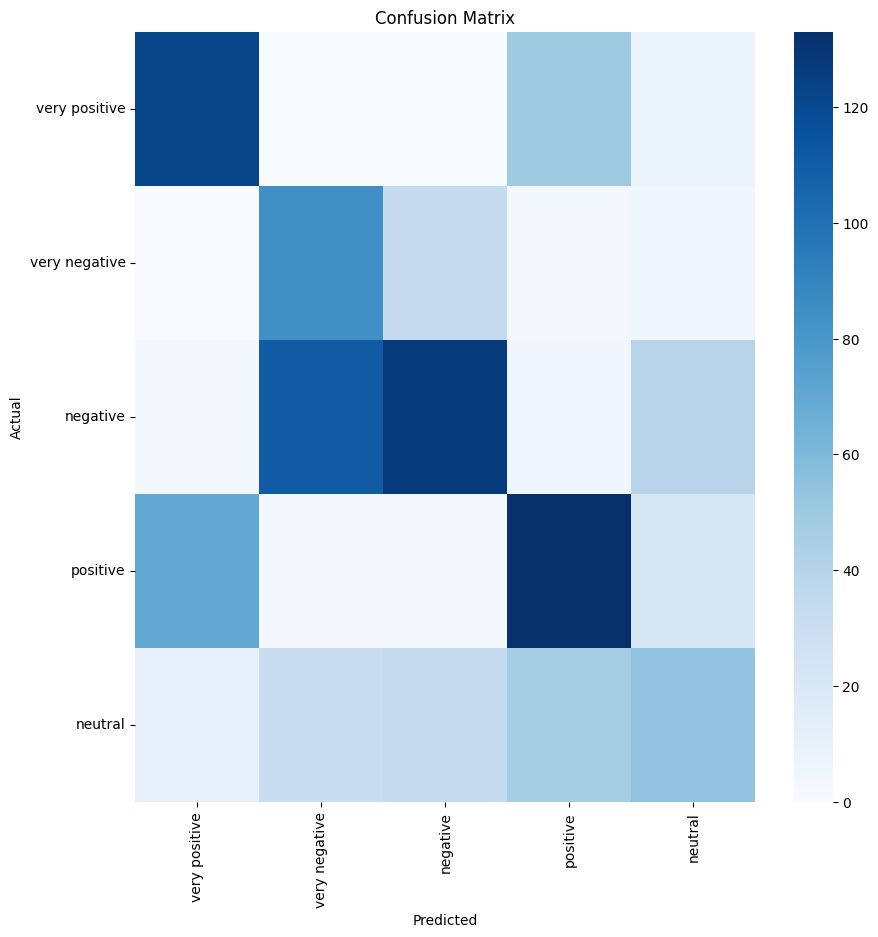

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(classes), yticklabels=list(classes))
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.xticks(rotation=90); plt.yticks(rotation=0)

In [21]:
from tqdm import tqdm
import numpy as np

prompt_lengths = []
input_lengths = []
shots_lengths = []
num_shots = []

for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Calculating token stats'):
    # get the most similar examples
    examples = get_few_shot_examples(i, ps, examples_per_class=2)

    if len(ps) > 1:
        # build the prompt (same as before)
        prompt = create_prompt(x, examples)["content"]

        # compute tokenized lengths
        prompt_len = len(llm.tokenizer(prompt)["input_ids"])
        input_len = len(llm.tokenizer(x)["input_ids"])
        # join the examples' text parts for shots length
        shots_text = "\n".join([ex[0] if isinstance(ex, (list, tuple)) else str(ex) for ex in examples])
        shots_len = len(llm.tokenizer(shots_text)["input_ids"])

        prompt_lengths.append(prompt_len)
        input_lengths.append(input_len)
        shots_lengths.append(shots_len)
        num_shots.append(len(examples))

# Print averages
print(f"Average prompt length: {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length: {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average number of shots: {np.mean(num_shots):.1f}")

Calculating token stats:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating token stats:   1%|          | 11/1000 [00:00<00:09, 99.71it/s]

Calculating token stats:   2%|▏         | 21/1000 [00:00<00:11, 88.66it/s]

Calculating token stats:   3%|▎         | 31/1000 [00:00<00:10, 89.85it/s]

Calculating token stats:   4%|▍         | 41/1000 [00:00<00:11, 82.00it/s]

...

Calculating token stats:  97%|█████████▋| 973/1000 [00:09<00:00, 116.96it/s]

Calculating token stats:  99%|█████████▊| 986/1000 [00:09<00:00, 119.96it/s]

Calculating token stats: 100%|█████████▉| 999/1000 [00:09<00:00, 113.82it/s]

Calculating token stats: 100%|██████████| 1000/1000 [00:09<00:00, 107.51it/s]

Average prompt length: 250.2 tokens
Average input length: 23.7 tokens
Average shots section length: 154.3 tokens
Average number of shots: 6.8


In [22]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/sst/results/predictions/sst-llama-3.1-8b-cicle-contriever-lr-2.0k-samples-2-shots-pc-0.05-α.json", set_sizes=set_sizes)

Results saved to: '/home/v25/ippa6201/cicle-evaluation/sst/results/predictions/sst-llama-3.1-8b-cicle-contriever-lr-2.0k-samples-2-shots-pc-0.05-α.json'


In [23]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/sst/results/lengths/sst-llama-3.1-8b-cicle-contriever-lr-2.0k-samples-2-shots-pc-0.05-α.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/sst/results/lengths/sst-llama-3.1-8b-cicle-contriever-lr-2.0k-samples-2-shots-pc-0.05-α.json'
